**Task 3: Churn Prediction Model**

Objective: Predict which users are likely to leave the platform.

Task Deliverables: Analyze user behavior (login frequency, course engagement). Use Random Forest or Gradient Boosting for prediction. 

Outcome: Reduce churn by offering personalized support. 

📊 Data Source: LMS engagement logs and user activity.

Libraries and dataset:

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load dataset
df = pd.read_csv("online_learning_engagement_dataset.csv")

# Clean non-negative features if necessary
num_cols = df.select_dtypes(include=["float64", "int64"]).columns
df[num_cols] = df[num_cols].clip(lower=0)

Features and target:

In [8]:
# 2. Features & target
feature_cols = [
    "study_hours_weekly",
    "login_frequency_weekly",
    "avg_session_duration_min",
    "video_watch_time_min",
    "assignments_submitted",
    "forum_posts",
    "quiz_attempts",
    "avg_quiz_score",
    "attendance_rate",
    "engagement_score",
]

X = df[feature_cols]
y = df["dropout"]

Train-test split & scaling:

In [9]:
# 3. Train-Test split & scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Model training:

In [10]:
# 4. Model Training
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_scaled, y_train)

# Predictions & Probabilities
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]
gb_preds = gb_model.predict(X_test_scaled)
gb_probs = gb_model.predict_proba(X_test_scaled)[:, 1]

Visualizations

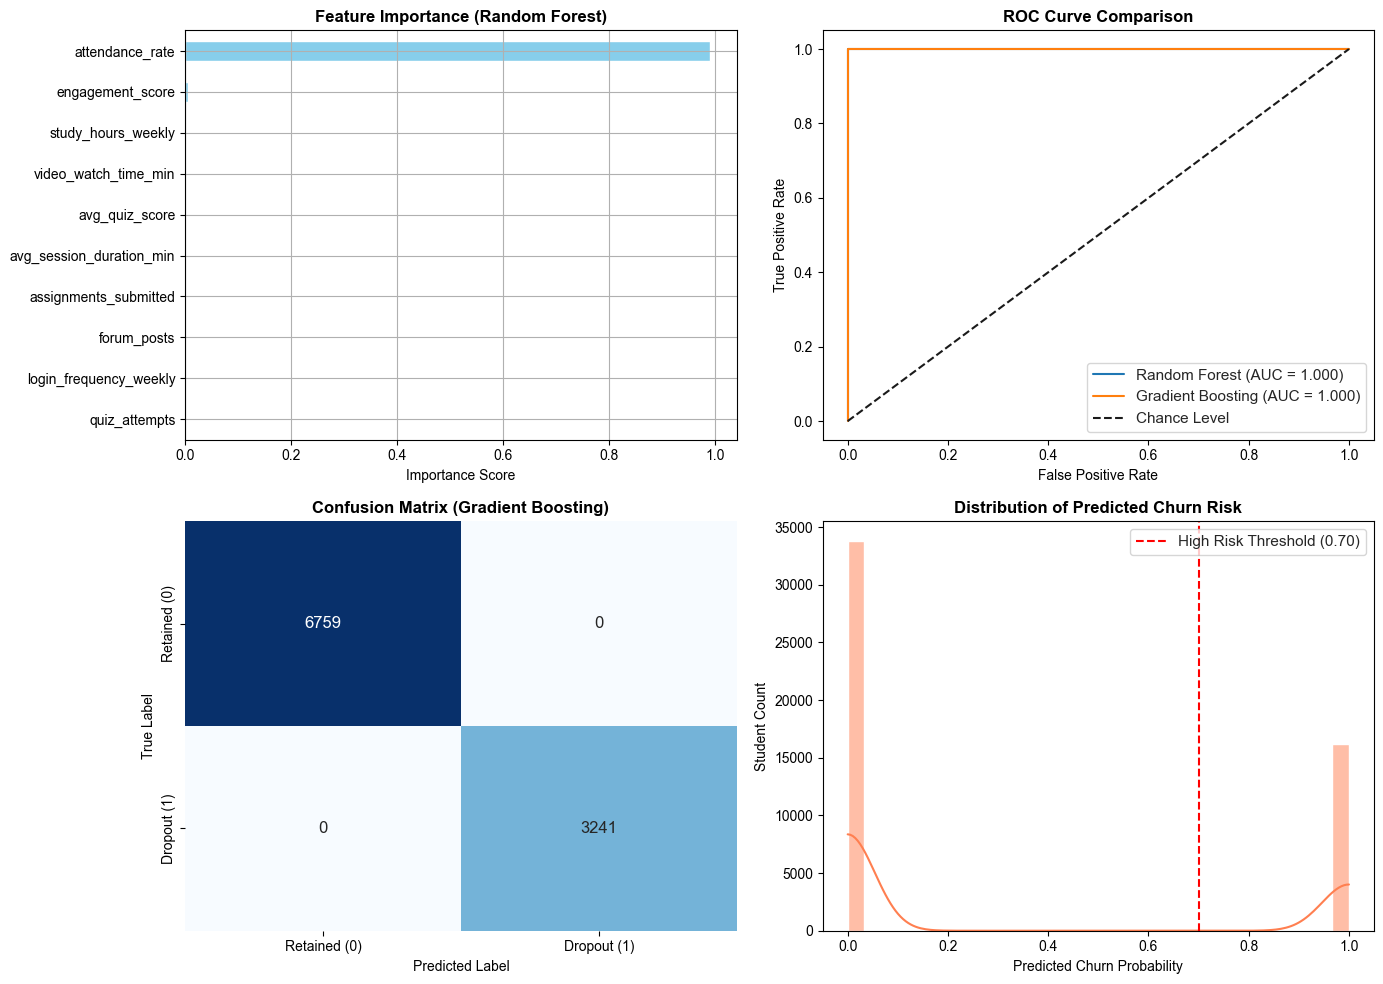

Gradient Boosting Evaluation
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6759
           1       1.00      1.00      1.00      3241

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [11]:
# 5. Visualizations setup
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.set_theme(style="whitegrid")

# Plot 1: Feature Importance (Random Forest)
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
importances.plot(kind="barh", ax=axes[0, 0], color="skyblue")
axes[0, 0].set_title("Feature Importance (Random Forest)", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Importance Score")

# Plot 2: ROC Curves
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_probs)

axes[0, 1].plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_probs):.3f})")
axes[0, 1].plot(gb_fpr, gb_tpr, label=f"Gradient Boosting (AUC = {roc_auc_score(y_test, gb_probs):.3f})")
axes[0, 1].plot([0, 1], [0, 1], "k--", label="Chance Level")
axes[0, 1].set_title("ROC Curve Comparison", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate")
axes[0, 1].legend()

# Plot 3: Confusion Matrix (Gradient Boosting)
cm = confusion_matrix(y_test, gb_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1, 0], cbar=False)
axes[1, 0].set_title("Confusion Matrix (Gradient Boosting)", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Predicted Label")
axes[1, 0].set_ylabel("True Label")
axes[1, 0].set_xticklabels(["Retained (0)", "Dropout (1)"])
axes[1, 0].set_yticklabels(["Retained (0)", "Dropout (1)"])

# Plot 4: Churn Risk Probability Distribution
df["churn_probability"] = gb_model.predict_proba(scaler.transform(X))[:, 1]
sns.histplot(df["churn_probability"], kde=True, ax=axes[1, 1], color="coral", bins=30)
axes[1, 1].axvline(0.70, color="red", linestyle="--", label="High Risk Threshold (0.70)")
axes[1, 1].set_title("Distribution of Predicted Churn Risk", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Predicted Churn Probability")
axes[1, 1].set_ylabel("Student Count")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# 6. Print summary
print("Gradient Boosting Evaluation")
print(classification_report(y_test, gb_preds))